In [15]:
import pandas as pd
import re
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *
import numpy as np

In [16]:
df = pd.read_excel(VALIDATION_SAMPLE)

## Technologies

In [17]:
def find_language_robust(tags_text, target_languages):
    """
    Check if any target language is present in the tags string using a robust
    regex that handles special characters like '+' and '#'.

    Returns the matched language (original capitalization) or 'n/a' if none found.
    """
    if pd.isna(tags_text) or not tags_text.strip():
        return 'n/a'

    tags_text_lower = tags_text.lower()

    for lang in target_languages:
        lang_lower = lang.lower()
        lang_escaped = re.escape(lang_lower)

        regex_search = r'(^|,\s*)' + lang_escaped + r'(\s*,|$)'

        if re.search(regex_search, tags_text_lower):
            return lang

    return 'n/a'


LANGUAGES = ['Python', 'JavaScript', 'Java', 'PHP', 'C++', 'C#', 'C', 'Obj-C', 'Go',
              'Perl', 'Ruby', 'Delphi', 'Powershell', 'SQL', 'TSQL', 'Vbnet', 'Lisp', 'Lua', 'Bash',
              'R', 'Haskell', 'Matlab', 'Rust']
LOWERCASE_LANGUAGES = [lang.lower() for lang in LANGUAGES]

# Apply language detection
df['language'] = df['technologies'].str.lower().apply(lambda x: find_language_robust(x, LANGUAGES))

In [18]:
language_percentages = df['language'].value_counts() / df.shape[0] * 100
language_percentages

language
n/a           58.028169
Java           9.014085
PHP            7.605634
Python         7.605634
C#             6.197183
C++            3.661972
Bash           1.408451
C              1.408451
Rust           0.845070
JavaScript     0.845070
Ruby           0.845070
Go             0.563380
SQL            0.563380
Lua            0.281690
Matlab         0.281690
Haskell        0.281690
R              0.281690
Powershell     0.281690
Name: count, dtype: float64

In [19]:
language_percentages = language_percentages.drop('n/a', errors='ignore')

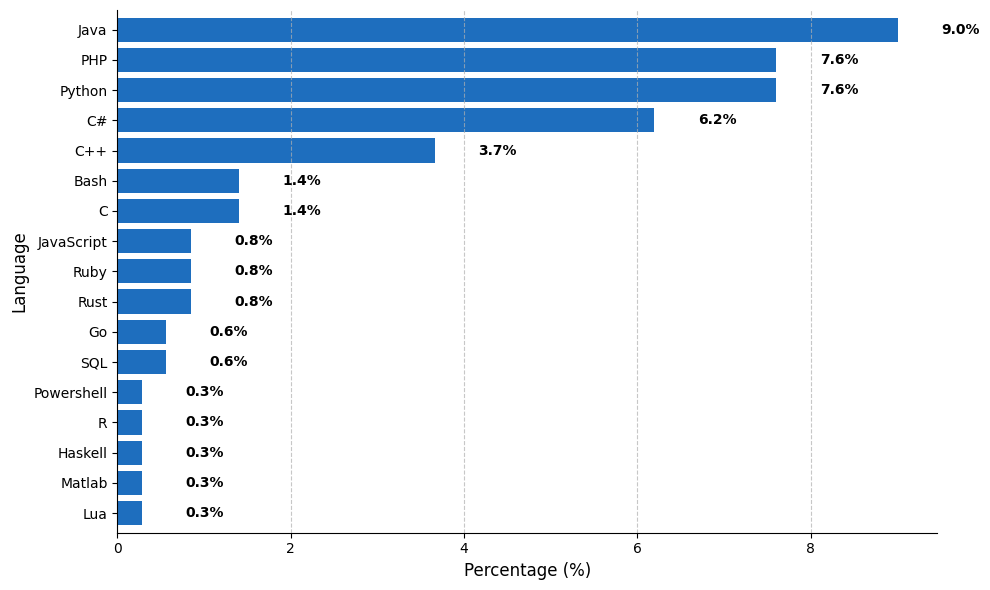

In [20]:
import matplotlib.pyplot as plt

language_percentages = language_percentages.sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = language_percentages.plot.barh(color="#1e6ebe", width=0.8)

#plt.title('Programming Languages Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Language', fontsize=12)

for i, v in enumerate(language_percentages):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)   
ax.spines['right'].set_visible(False) 
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(LANGUAGES_DISTRIBUTION, dpi=600, bbox_inches='tight')
plt.show()


In [21]:
def remove_languages_from_technologies(tech_string, languages_to_remove):
    """
    Remove the specified languages from the technologies string.
    Returns 'n/a' if the resulting list is empty or input is missing.
    """
    if pd.isna(tech_string) or not tech_string.strip():
        return 'n/a'
    
    tech_list = [tech.strip() for tech in tech_string.split(',')]
    filtered_list = [tech for tech in tech_list if tech.lower() not in [lang.lower() for lang in languages_to_remove]]
    
    return ', '.join(filtered_list) if filtered_list else 'n/a'


# Apply language removal to create a cleaned technologies column
df['technologies_clean'] = df['technologies'].apply(lambda x: remove_languages_from_technologies(x, LANGUAGES))

In [22]:
def normalize_technology_terms(cell: str) -> str:
    """Normalize technology terms to canonical short forms."""
    if not isinstance(cell, str):
        return cell

    normalization_map = {
        "aes-128": "aes",
        "aes-256": "aes",
        "rijndael": "aes",
        "aes-ni": "aes",

        "pkcs1": "pkcs",
        "pkcs#1": "pkcs",
        "pkcs5": "pkcs",
        "pkcs#5": "pkcs",
        "pkcs7": "pkcs",
        "pkcs#7": "pkcs",
        "pkcs11": "pkcs",
        "pkcs11.net": "pkcs",
        "pkcs11interop": "pkcs",
        "pkcs12": "pkcs",
        "pkcs#12": "pkcs",

        "sha1": "sha1",
        "sha-1": "sha1",
        "sha256": "sha",
        "sha-256": "sha",
        "sha512": "sha",
        "sha-512": "sha",
        "sha2": "sha",
    }

    normalized_terms = []

    for term in cell.split(","):
        t = term.strip().lower()
        t = re.sub(r"\s+", " ", t)
        normalized_terms.append(normalization_map.get(t, t))

    return ", ".join(normalized_terms)


# Apply normalization to cleaned technologies
df['technologies_clean'] = df['technologies_clean'].apply(normalize_technology_terms)

In [23]:
exploded = (
    df['technologies_clean']
        .str.split(',')
        .explode()
        .str.strip()
        .str.replace('\xa0', '', regex=False)
        .str.lower()
        .replace('', pd.NA)
        .dropna()
)
clean_word_counts = exploded.value_counts()

In [24]:
len(exploded.unique())  # Total unique techs n - 1 | dont count with n/a

190

In [25]:
pd.set_option('display.max_rows', None)
clean_word_counts / df.shape[0] * 100

technologies_clean
openssl                  20.563380
aes                      16.056338
sha                      13.521127
md5                      10.704225
rsa                      10.140845
n/a                       8.450704
ssl                       8.169014
pkcs                      5.915493
.net                      5.352113
hash                      4.225352
base64                    4.225352
sha1                      3.943662
iv                        3.943662
tls                       3.380282
xor                       3.380282
cbc                       3.098592
bcrypt                    2.816901
pgp                       2.535211
mysql                     1.690141
ctr                       1.408451
ssh                       1.408451
bouncycastle              1.408451
ecb                       1.408451
pbkdf                     1.408451
node.js                   1.126761
gpg                       1.126761
truecrypt                 1.126761
mac                       1.126761
g

## Technologies Along Topics


In [26]:
# Same numbers as the table of RQ1 in article
topic_names = {
    "01": "OpenSSL installation/build and runtime errors",
    "02": "Encoding and byte/string conversions (Base64, binary)",
    "03": "X.509 certificates, signing, and trust chains",
    "04": "Password hashing with salt (bcrypt, rainbow tables)",
    "05": "Crypto library/API implementation in code",
    "06": "Number theory for crypto (primes, factoring, modular arithmetic)",
    "07": "Public-key cryptography: encryption and digital signatures",
    "08": "Block cipher modes, IV/nonce, and padding",
    "09": "Client-server secure communication (HTTP/HTTPS, sessions)",
    "10": "User authentication and account management",
    "11": "File handling, integrity checks & checksums",
    "12": "Security vs performance (cost, speed, hardware limits)",
    "13": "Password strength and entropy estimation",
    "14": "Secure random number generation (entropy, seeding, PRNG)",
    "15": "Cryptographic hash functions & collisions",
    "16": "Key sizes and security parameters selection",
    "17": "Key protection on devices (memory/disk access, threat model)",
    "18": "Application data encryption & key storage",
    "19": "Cryptosystem design pitfalls & attack resistance",
    "20": "Trust, vendors, and real-world security risk",
    "21": "Conceptual crypto explanations and learning",
}


# Manual selected terms. The percentages should be the same as the output of the previous cell    
crypto_technologies = {
    "Cryptographic Libraries": [
        "openssl (20.563380)",
        "crypto++ (0.845070)",
        "pycrypto (1.126761)",
        "libsodium (0.563380)",
        "mcrypt (0.563380)",
        "libtomcrypt (0.281690)",
        "pycryptopp (0.281690)",
        "as3crypto (0.281690)",
        "bouncycastle (1.408451)",
        "pyopenssl (0.845070)",
        "scrypt (0.845070)",
        "crypto-js (0.563380)",
        "itsdangerous (0.281690)",
        "keyczar (0.281690)",
        "pycryptodome (0.281690)",
        "python-cryptography (0.281690)",
        "libssl (0.845070)",
        "libcrypto (0.563380)"
    ],
    
    "Cryptography Algorithms": [
        "aes (16.056338)",
        "rsa (10.140845)",
        "sha (13.521127)",
        "md5 (10.704225)",
        "xor (3.380282)",
        "bcrypt (2.816901)",
        "des (0.563380)",
        "blowfish (0.281690)",
        "twofish (0.281690)",
        "serpent (0.281690)",
        "md2 (0.281690)",
        "arc4 (0.281690)",
        "rc4 (0.281690)",
        "paillier (0.281690)"
    ],
    
    "Hash Functions and HMAC": [
        "hash (4.225352)",
        "sha1 (3.943662)",
        "hmac (0.563380)",
        "hmacsha1 (0.563380)",
        "blake2bp (0.281690)"
    ],
    
    "Operation Modes": [
        "cbc (3.098592)",
        "ctr (1.408451)",
        "ecb (1.408451)",
        "gcm (1.126761)",
        "ofb (0.281690)",
        "cfb (0.281690)",
        "siv (0.281690)",
        "xex (0.563380)",
        "ocb2 (0.281690)"
    ],
    
    "Security Protocols": [
        "ssl (8.169014)",
        "tls (3.380282)",
        "ssh (1.408451)",
        "https (1.126761)",
        "vpn (0.563380)",
        "openvpn (0.563380)"
    ],
    
    "PKI and Certificates": [
        "pkcs (5.915493)",
        "x509 (0.845070)",
        "pgp (2.535211)",
        "gpg (1.126761)",
        "openpgp (0.563380)",
        "s/mime (0.281690)",
        "pki (0.281690)",
        "crl (0.281690)",
        "ssl ocsp (0.281690)"
    ],
    
    "Public-Key Cryptography": [
        "public-key (0.563380)",
        "ecdsa (0.563380)",
        "ecc (0.845070)",
        "diffie-hellman (0.563380)",
        "dh (0.281690)",
        "public-key-encryption (0.281690)"
    ],
    
    "Key Derivation and KDF": [
        "pbkdf (1.408451)",
        "pbkdf2 (0.563380)",
        "argon2 (0.845070)",
        "csprng (0.281690)",
        "node-scrypt (0.281690)"
    ],
    
    "Encoding and Utilities": [
        "base64 (4.225352)",
        "iv (3.943662)",
        "mac (1.126761)",
        "otp (0.563380)",
        "oaep (0.563380)",
        "rsa-oaep (0.281690)",
        "aad (0.281690)",
        "aead (0.281690)",
        "eme (0.281690)",
        "prp (0.281690)",
        "kcv (0.281690)",
        "key rotation (0.281690)"
    ],
    
    "Hardware and Security Modules": [
        "tpm (0.845070)",
        "hsm (0.281690)",
        "nitrokey (0.281690)",
        "smartcard-hsm (0.281690)",
        "ncryptoki (0.563380)",
        "trng (0.281690)",
        "kryptorfpga (0.281690)",
        "cryptechalpha (0.281690)"
    ],
    
    "Cryptography Tools": [
        "truecrypt (1.126761)",
        "veracrypt (0.281690)",
        "diceware (1.126761)",
        "zxcvbn (0.563380)",
        "keytool (0.845070)",
        "xca (0.281690)",
        "sqlcipher (0.281690)",
        "disk encryption (0.281690)",
        "luks (0.563380)",
        "steganography (0.563380)",
        "xsteg (0.281690)",
        "stegbreak (0.281690)"
    ],
    
    "Application Security": [
        "csrf (0.563380)",
        "cors (0.281690)",
        "oauth2 (0.281690)",
        "sso (0.281690)",
        "backdoors (0.281690)",
        "nsa (0.281690)",
        "webcrypto-api (0.281690)"
    ],
    
    "Platforms and Development Environments": [
        ".net (5.352113)",
        "asp.net (0.845070)",
        "node.js (1.126761)",
        "jce (0.563380)",
        "cryptoapi (0.563380)",
        "xamarin (0.563380)",
        "xcode (0.563380)",
        "django (0.563380)",
        "react native (0.281690)",
        "swift3 (0.281690)",
        "cordova (0.281690)",
        "javax (0.281690)",
        "firemonkey (0.281690)",
        "apk (0.281690)",
        "visual studio (0.281690)"
    ],
    
    "Concepts and Theoretical Models": [
        "block-cipher (0.563380)",
        "cpa-security (0.563380)",
        "cca (0.563380)",
        "m-cca2 (0.281690)",
        "rfc (0.281690)"
    ],
    
    "Other": [
        "mysql (1.690141)",
        "homebrew (0.845070)",
        "mongodb (0.281690)",
        "nginx (0.281690)",
        "cmake (0.563380)",
        "git (0.563380)",
        "docker (0.281690)",
        "aws (0.281690)",
        "udp (0.563380)",
        "http (0.563380)",
        "tcp (0.281690)",
        "smtp (0.281690)",
        "mingw (0.281690)",
        "gcc (0.281690)",
        "json (0.281690)",
        "pdf (0.281690)",
        "sqlite (0.281690)",
        "pandas (0.281690)",
        "gcp (0.281690)",
        "cloudflare (0.281690)",
        "sql server (0.281690)",
        "codeigniter (0.281690)",
        "struts2 (0.281690)",
        "typo3 (0.281690)",
        "xampp (0.281690)",
        "itext (0.281690)",
        "debian (0.281690)",
        "manjaro (0.281690)",
        "boto (0.281690)",
        "lts (0.281690)",
        "solana (0.281690)",
        "hdfs (0.281690)",
        "tar (0.281690)",
        "mplayer (0.281690)",
        "luabit (0.281690)",
        "bitlib (0.281690)",
        "libcurl (0.281690)",
        "libss (0.281690)",
        "gnutls (0.281690)",
        "xcb (0.281690)",
        "keychain (0.281690)",
        "orapki (0.281690)",
        "comodo (0.281690)",
        "signtool (0.281690)",
        "pfx (0.281690)",
        "savon (0.281690)",
        "dotpeek (0.281690)",
        ".net reflector (0.281690)",
        "agcd (0.281690)",
        "ecm (0.281690)",
        "tme (0.281690)",
        "feal-4 (0.281690)",
        "jizz-jazz (0.281690)",
        "xored (0.281690)",
        "cryptocode (0.281690)",
        "crypto5 (0.281690)",
        "pythoncrypter (0.281690)",
        "cryptopp562 (0.281690)",
        "n/a (8.450704)"
    ]
}


In [75]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import os

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

MIN_TOPICS_CROSS  = 4
MIN_PEAK_SPECIFIC = 8.0

CELL_HEIGHT = 0.25   # inches per technology row
CELL_WIDTH  = 0.55   # inches per topic column

TYPE_ORDER  = ["cross-cutting", "topic-specific", "sparse"]
TYPE_COLORS = {
    "cross-cutting":  "#185FA5",
    "topic-specific": "#3B6D11",
    "sparse":         "#888780",
}
TYPE_LABELS = {
    "cross-cutting":  "Cross-cutting",
    "topic-specific": "Topic-specific",
    "sparse":         "Sparse",
}

OMIT_CATEGORIES = {
    "Encoding and Utilities",
    "Concepts and Theoretical Models",
    "Hardware and Security Modules",
    "Security Protocols",
    "Application Security",
    "Other",
}


def generate_heatmap(omit_like_article: bool = False):

    # ── Pre-processing ────────────────────────────────────────────────────────
    tmp_df = df[['topic', 'technologies_clean']].copy()
    tmp_df['post_id'] = tmp_df.index
    tmp_df = tmp_df.assign(tech=tmp_df['technologies_clean'].str.split(',')).explode('tech')
    tmp_df['tech'] = tmp_df['tech'].astype(str).str.strip().str.lower()
    tmp_df['tech'] = (
        tmp_df['tech']
        .replace({'': 'n/a', 'nan': 'n/a', 'none': 'n/a'})
        .fillna('n/a')
    )

    posts_per_topic = df.groupby('topic').size().to_dict()

    tech_topic_counts = (
        tmp_df
        .groupby(['tech', 'topic'])['post_id']
        .nunique()
        .reset_index(name='count')
    )
    tech_topic_counts['pct'] = tech_topic_counts.apply(
        lambda row: (row['count'] / posts_per_topic.get(row['topic'], 1)) * 100,
        axis=1,
    )

    name_to_id = {v: k for k, v in topic_names.items()}
    tech_topic_counts['topic_id'] = tech_topic_counts['topic'].map(name_to_id)
    topic_ids_sorted = [f"{i:02d}" for i in range(1, 22)]

    output_dir = NOTEBOOK_OUTPUTS / 'rq3' / 'plots'
    os.makedirs(output_dir, exist_ok=True)

    # ── Helpers ───────────────────────────────────────────────────────────────
    def classify_tech(row_series: pd.Series) -> str:
        non_zero = (row_series > 0).sum()
        max_freq  = row_series.max()
        if non_zero >= MIN_TOPICS_CROSS:
            return "cross-cutting"
        if max_freq >= MIN_PEAK_SPECIFIC:
            return "topic-specific"
        return "sparse"

    def build_combined_df() -> pd.DataFrame:
        frames = []
        for categoria, tecnologias_com_pct in crypto_technologies.items():

            if omit_like_article and categoria in OMIT_CATEGORIES:
                continue

            tecnologias = [t.split(' (')[0].strip().lower() for t in tecnologias_com_pct]
            cat_data = tech_topic_counts[tech_topic_counts['tech'].isin(tecnologias)].copy()
            if cat_data.empty:
                continue

            pivot = (
                cat_data
                .pivot(index='tech', columns='topic_id', values='pct')
                .fillna(0)
            )
            pivot = pivot.reindex(columns=topic_ids_sorted, fill_value=0)
            pivot.index = pivot.index.str.upper()
            pivot = pivot.rename(index={'NAN': 'N/A', '': 'N/A'})

            tech_order = [t.split(' (')[0].strip().upper() for t in tecnologias_com_pct]
            tech_order = [t for t in tech_order if t in pivot.index]
            pivot = pivot.reindex(tech_order)

            pivot['_categoria']  = categoria
            pivot['_type']       = pivot[topic_ids_sorted].apply(classify_tech, axis=1)
            pivot['_n_topics']   = (pivot[topic_ids_sorted] > 0).sum(axis=1)
            pivot['_max_freq']   = pivot[topic_ids_sorted].max(axis=1)
            pivot['_type_order'] = pivot['_type'].map({t: i for i, t in enumerate(TYPE_ORDER)})
            frames.append(pivot)

        combined = pd.concat(frames)
        combined = combined.sort_values(
            ['_categoria', '_type_order', '_n_topics', '_max_freq'],
            ascending=[True, True, False, False],
        )
        return combined

    def render(combined: pd.DataFrame):
        plot_data  = combined[topic_ids_sorted].copy()
        tech_types = combined['_type'].tolist()
        tech_cats  = combined['_categoria'].tolist()
        tech_n     = combined['_n_topics'].tolist()
        n_techs    = len(plot_data)
        n_topics   = len(topic_ids_sorted)

        fig_width  = max(16, n_topics * CELL_WIDTH)
        fig_height = max(8,  n_techs  * CELL_HEIGHT)

        if n_techs <= 10:
            pad_value, fraction_value = 0.02, 0.04
        elif n_techs <= 20:
            pad_value, fraction_value = 0.03, 0.03
        else:
            pad_value, fraction_value = 0.02, 0.025

        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        mask = plot_data == 0
        sns.heatmap(
            plot_data,
            annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.6, linecolor='white',
            mask=mask, vmin=0, vmax=100,
            square=False, ax=ax,
            annot_kws={'size': 8},
            cbar=True,
            cbar_kws={
                'orientation': 'vertical',
                'pad': pad_value,
                'shrink': 0.7,
                'aspect': 25,
                'fraction': fraction_value,
                'label': 'Relative frequency (%)',
            },
        )

        labels = [f"{name}  [{n}T]" for name, n in zip(combined.index, tech_n)]
        ax.set_yticklabels(labels, rotation=0, fontsize=8.5)
        for tick, typ in zip(ax.get_yticklabels(), tech_types):
            tick.set_color(TYPE_COLORS[typ])

        prev_cat = None

        # garante renderer disponível
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        inv = ax.transAxes.inverted()

        for i, (cat, typ) in enumerate(zip(tech_cats, tech_types)):

            if cat != prev_cat:

                y_pos = i - 0.1

                # ── TEXTO DA CATEGORIA ───────────────────────────────────
                text = ax.text(
                    0, y_pos,
                    f"{cat}",
                    ha='left', va='center',
                    fontsize=7.5, fontweight='bold', color='#222',
                    transform=ax.get_yaxis_transform(),
                    clip_on=False,
                )

                # ── MEDIR TEXTO ──────────────────────────────────────────
                fig.canvas.draw()
                bbox = text.get_window_extent(renderer=renderer)
                (x0, _), (x1, _) = inv.transform([
                    (bbox.x0, bbox.y0),
                    (bbox.x1, bbox.y1)
                ])

                # ── LINHA COMEÇA APÓS TEXTO ──────────────────────────────
                line = ax.hlines(
                    y=y_pos,
                    xmin=x1 + 0.003,
                    xmax=1,
                    transform=ax.get_yaxis_transform(),
                    color='#222',
                    linewidth=1.2,
                    linestyle='--',
                    alpha=0.6,
                )
                line.set_clip_on(False)  # ← permite renderizar fora dos limites do eixo

                prev_cat = cat

        x_labels = [f'T{int(col)}' for col in topic_ids_sorted]
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)
        ax.set_xlabel('Topics (ID)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Technologies', fontsize=12, fontweight='bold')

        ax.set_axisbelow(True)
        ax.grid(which='major', color='lightgray', linestyle='--', linewidth=0.5, alpha=0.6)

        patches = [
            mpatches.Patch(color=TYPE_COLORS[t], label=TYPE_LABELS[t])
            for t in TYPE_ORDER
        ]
        ax.legend(
            handles=patches, loc='upper right',
            fontsize=8, frameon=True, framealpha=0.9,
            edgecolor='lightgray', borderpad=0.6,
        )

        plt.tight_layout()
        return fig

    # ── Build, render, save ───────────────────────────────────────────────────
    suffix = "short" if omit_like_article else "full"
    filename = f"heatmap_combined_{suffix}.pdf"

    print("Building combined dataset...")
    combined = build_combined_df()
    print(f"  {len(combined)} technologies across {combined['_categoria'].nunique()} categories")

    fig = render(combined)

    output_path = os.path.join(output_dir, filename)
    fig.savefig(output_path, dpi=600, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")


generate_heatmap()                        # → heatmap_combined_full.pdf
generate_heatmap(omit_like_article=True)  # → heatmap_combined_short.pdf

Building combined dataset...
  190 technologies across 15 categories
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatmap_combined_full.pdf
Building combined dataset...
  93 technologies across 9 categories
Saved: C:\dev\social-media-dev-crawler\data\notebook_outputs\rq3\plots\heatmap_combined_short.pdf


## Technologies Over Time


In [28]:
df = pd.read_csv(CLASSIFIED_POSTS)
df = df[df['type'] == 'question']

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\dev\\social-media-dev-crawler\\data\\Lda\\csvs\\classified_posts.csv'

In [ ]:

df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')
df['year'] = df['creation_date'].dt.year

topic_by_year = df.groupby(['year', 'topic']).size().reset_index(name='count')
total_by_year = df.groupby('year').size().reset_index(name='total')

topic_by_year = topic_by_year.merge(total_by_year, on='year')
topic_by_year['percentage'] = (topic_by_year['count'] / topic_by_year['total']) * 100

ordered_keys = sorted(topic_names.keys())

topics_per_fig = 7
num_figs = 3

for fig_idx in range(num_figs):
    start_idx = fig_idx * topics_per_fig
    end_idx = start_idx + topics_per_fig
    current_keys = ordered_keys[start_idx:end_idx]
    
    n_topics_in_fig = len(current_keys)

    fig, axes = plt.subplots(n_topics_in_fig, 1, figsize=(9, 1.5 * n_topics_in_fig), sharex=True)
    
    if n_topics_in_fig == 1:
        axes = [axes]
    
    colors = plt.cm.tab10(range(10))

    for idx, key in enumerate(current_keys):
        ax = axes[idx]
        ax2 = ax.twinx()
        
        topic_name = topic_names[key]
        topic_data = topic_by_year[topic_by_year['topic'] == topic_name].sort_values('year')
        
        if not topic_data.empty:
            global_idx = start_idx + idx
            color = colors[global_idx % 10]

            line1 = ax.plot(topic_data['year'], topic_data['count'], 
                            marker='o', linewidth=2, markersize=4, 
                            color=color, label='Count (left axis)',
                            linestyle='-', alpha=0.8)
            
            line2 = ax2.plot(topic_data['year'], topic_data['percentage'], 
                            marker='s', linewidth=2, markersize=3,
                            color=color, label='Percentage (right axis)',
                            linestyle='--', alpha=0.6)
        
        ax.set_ylabel('Count', fontsize=8, fontweight='bold')
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        
        ax2.set_ylabel('Percentage', fontsize=8, fontweight='bold', rotation=270, labelpad=12)
        ax2.tick_params(axis='y', labelsize=7)
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
        
        ax.set_title(f'T{key}: {topic_name}', fontsize=9, fontweight='bold', loc='left', pad=3)
        
        if idx < n_topics_in_fig - 1:
            ax.tick_params(labelbottom=False)
        
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, ['Count (left)', 'Percentage (right)'], 
                  loc='upper right', fontsize=6, framealpha=0.9)

    axes[-1].set_xlabel('Year', fontsize=9, fontweight='bold')
    axes[-1].tick_params(axis='x', labelsize=8, rotation=45)

    plt.suptitle(f'Topics Evolution (Part {fig_idx + 1}/3)', 
                  fontsize=12, fontweight='bold', y=0.998)
    
    plt.tight_layout()
    plt.savefig(NOTEBOOK_OUTPUTS / 'rq3' / 'plots' / f'topics-evolution-{fig_idx + 1}.png', dpi=300, bbox_inches='tight')
    plt.subplots_adjust(hspace=0.3)
    plt.show()


KeyError: 'creation_date'